In [1]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import os



In [13]:
# 1. Update these arrays with your exact 10 filenames
online_files = [
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/online_llm_medmcqa_gemini_results.csv',
    #'/Users/akshaybusareddy/Gemini3_Flash_Hallucination_Results.csv',
    '/Users/akshaybusareddy/results_final/medmcqa_hallucination_full_online.csv'
]

offline_files = [
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/offline_llm_medmcqa_results_meditron3.csv',
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/llama4_scout_moe_medmcqa_results.csv',
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/med42_medmcqa_results-70b.csv',
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/openbiollm_70b_medmcqa_results.csv',
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/cloud_llm_medmcqa_results_Nemotron70B.csv',
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/offline_llm_medmcqa_results_LLama_med42-8b.csv',
]

In [14]:
def load_and_prep_data():
    """Loops through all files, adds metadata, and combines into one huge DataFrame."""
    dfs = []
    
    # Combine lists so we can loop through them together
    all_files = [(f, 'Online') for f in online_files] + [(f, 'Offline') for f in offline_files]
    
    for file, model_type in all_files:
        if not os.path.exists(file): 
            print(f"[WARNING] File not found on computer: {file}")
            continue
            
        try:
            # Read the CSV
            df = pd.read_csv(file)
            
            # BULLETPROOFING: Strip whitespace and make all column names lowercase
            # This fixes issues like " Question", "question ", or "\ufeffquestion"
            df.rename(columns=lambda x: str(x).strip().replace('\ufeff', '').lower(), inplace=True)
            
            # Check if 'question' exists after cleanup
            if 'question' in df.columns:
                df = df[df['question'] != 'SUMMARY_METRICS'].copy()
            else:
                print(f"[ERROR] Skipping {file}: No 'question' column found. Columns found were: {list(df.columns)}")
                continue # Skip to the next file
            
            # Safely standardize boolean columns (defaults to False if missing)
            if 'is_accurate' in df.columns:
                df['is_accurate'] = df['is_accurate'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(bool)
            else:
                df['is_accurate'] = False
                
            if 'is_hallucinating' in df.columns:
                df['is_hallucinating'] = df['is_hallucinating'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(bool)
            else:
                df['is_hallucinating'] = False
                
            # Safely handle semantic score
            if 'semantic_score' in df.columns:
                df['semantic_score'] = pd.to_numeric(df['semantic_score'], errors='coerce')
            else:
                df['semantic_score'] = 0.0
            
            # Safely handle the explanation column
            if 'explanation_and_medication' in df.columns:
                df['explanation_length'] = df['explanation_and_medication'].astype(str).apply(len)
            elif 'explanation' in df.columns:
                df['explanation_length'] = df['explanation'].astype(str).apply(len)
            else:
                df['explanation_length'] = 0 # Default if column doesn't exist
                
            # Add metadata features
            df['model_name'] = os.path.basename(file).replace('.csv', '')
            df['model_type'] = model_type
            dfs.append(df)
            
        except Exception as e:
            print(f"[ERROR] Could not process {file}. Reason: {e}")
            
    if not dfs:
        raise ValueError("No valid files were processed! Please check the console errors above.")
        
    return pd.concat(dfs, ignore_index=True)

DEEP INSIGHTS REPORT (10 MODELS)

[1] QUESTION DIFFICULTY:
Out of 400 unique questions, 116 questions were missed by EVERY single model.
Example hardest question: 23 serotypes pneumococcal vaccine Most useful in ...

[2] VERBOSITY (AVERAGE EXPLANATION LENGTH IN CHARACTERS):
model_type
Offline     800.0
Online     1140.0

[3] THE ONLINE EDGE:
There are 0 questions where ALL offline models failed, but at least one online model succeeded.

[4] STATISTICAL SIGNIFICANCE (T-TEST ON SEMANTIC SCORES):
P-value: 0.74299
Conclusion: The difference in semantic scores between Online and Offline cohorts is NOT statistically significant.

[!] Generated 'semantic_score_distribution.png' successfully.


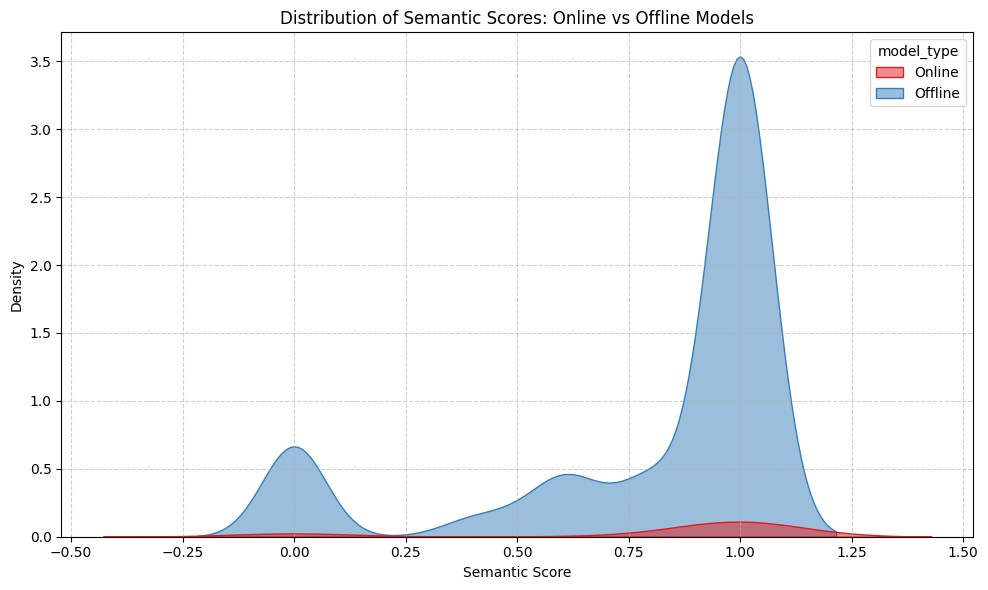

In [19]:


all_data = load_and_prep_data()

print("="*50)
print("DEEP INSIGHTS REPORT (10 MODELS)")
print("="*50)
# --- INSIGHT 1: QUESTION DIFFICULTY (THE HARDEST QUESTIONS) ---
# Which questions stumped the most models?
question_stats = all_data.groupby('question').agg(
    accuracy=('is_accurate', 'mean'),
    hallucination_rate=('is_hallucinating', 'mean'),
    times_asked=('model_name', 'count')
).reset_index()

# Find questions where accuracy is 0.0 (meaning ALL 10 models got it wrong)
hardest_questions = question_stats[question_stats['accuracy'] == 0.0]

print(f"\n[1] QUESTION DIFFICULTY:")
print(f"Out of {len(question_stats)} unique questions, {len(hardest_questions)} questions were missed by EVERY single model.")
if not hardest_questions.empty:
    print("Example hardest question:", hardest_questions['question'].iloc[0][:120], "...")
# --- INSIGHT 2: EXPLANATION VERBOSITY ---
# Do online models "talk" more?
print("\n[2] VERBOSITY (AVERAGE EXPLANATION LENGTH IN CHARACTERS):")
length_stats = all_data.groupby('model_type')['explanation_length'].mean().round(0)
print(length_stats.to_string())

# --- INSIGHT 3: THE "ONLINE EDGE" (CONSENSUS ANALYSIS) ---
# Did online models get questions right that offline models completely failed on?
pivot_acc = all_data.pivot_table(index='question', columns='model_type', values='is_accurate', aggfunc='mean')
pivot_acc.columns = ['Offline_Avg_Acc', 'Online_Avg_Acc']

# Find where offline accuracy was 0%, but online accuracy was > 0%
online_edge_questions = pivot_acc[(pivot_acc['Offline_Avg_Acc'] == 0.0) & (pivot_acc['Online_Avg_Acc'] > 0.0)]
print(f"\n[3] THE ONLINE EDGE:")
print(f"There are {len(online_edge_questions)} questions where ALL offline models failed, but at least one online model succeeded.")

# --- INSIGHT 4: STATISTICAL SIGNIFICANCE (WELCH'S T-TEST) ---
# Is the difference in semantic scores actually statistically significant?
online_scores = all_data[all_data['model_type'] == 'Online']['semantic_score'].dropna()
offline_scores = all_data[all_data['model_type'] == 'Offline']['semantic_score'].dropna()

t_stat, p_val = stats.ttest_ind(online_scores, offline_scores, equal_var=False)

print("\n[4] STATISTICAL SIGNIFICANCE (T-TEST ON SEMANTIC SCORES):")
print(f"P-value: {p_val:.5f}")
if p_val < 0.05:
    print("Conclusion: The difference in semantic scores between Online and Offline cohorts IS statistically significant.")
else:
    print("Conclusion: The difference in semantic scores between Online and Offline cohorts is NOT statistically significant.")

# --- INSIGHT 5: GENERATE DISTRIBUTION PLOT ---
# Visualizing the distribution of semantic scores between the two cohorts
plt.figure(figsize=(10, 6))
sns.kdeplot(data=all_data, x='semantic_score', hue='model_type', fill=True, alpha=0.5, palette='Set1')
plt.title('Distribution of Semantic Scores: Online vs Offline Models')
plt.xlabel('Semantic Score')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('semantic_score_distribution.png')
print("\n[!] Generated 'semantic_score_distribution.png' successfully.")

Loading datasets...
Successfully loaded 8 models with 2528 total responses.

DEEP INSIGHTS REPORT

[1] QUESTION DIFFICULTY:
Out of 400 unique questions, 116 questions were missed by EVERY single model.

[2] VERBOSITY (AVERAGE EXPLANATION LENGTH IN CHARACTERS):
model_type
Offline     800.0
Online     1140.0

[3] STATISTICAL SIGNIFICANCE (T-TEST ON SEMANTIC SCORES):
P-value: 0.74299
Conclusion: The difference in semantic scores between Online and Offline models is NOT statistically significant.

Generating visual dashboard...


/var/folders/nq/9q75pyvx5szfm000gjhp6h980000gn/T/ipykernel_36149/1275769628.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=acc_data, x='model_name', y='is_accurate', order=model_order_acc, palette='Blues_d', ax=ax1)
/var/folders/nq/9q75pyvx5szfm000gjhp6h980000gn/T/ipykernel_36149/1275769628.py:135: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/var/folders/nq/9q75pyvx5szfm000gjhp6h980000gn/T/ipykernel_36149/1275769628.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hal_data, x='model_name', y='is_hallucinating', order

Done! Dashboard saved as 'medmcqa_hallucination_dashboard.png'

CORE PERFORMANCE METRICS: ACCURACY VS HALLUCINATION
                           Model Name Category  Accuracy (%)  Hallucination Rate (%)
     llama4_scout_moe_medmcqa_results  Offline         56.00                   34.50
       openbiollm_70b_medmcqa_results  Offline         35.00                   17.00
cloud_llm_medmcqa_results_Nemotron70B  Offline         34.50                   36.75
                       gemini_results   Online         33.33                    3.70
            med42_medmcqa_results-70b  Offline         32.00                    7.75
                            meditron3  Offline         31.00                   47.25
                       LLama_med42-8b  Offline         30.00                   13.00
    medmcqa_hallucination_full_online   Online          0.00                    0.00


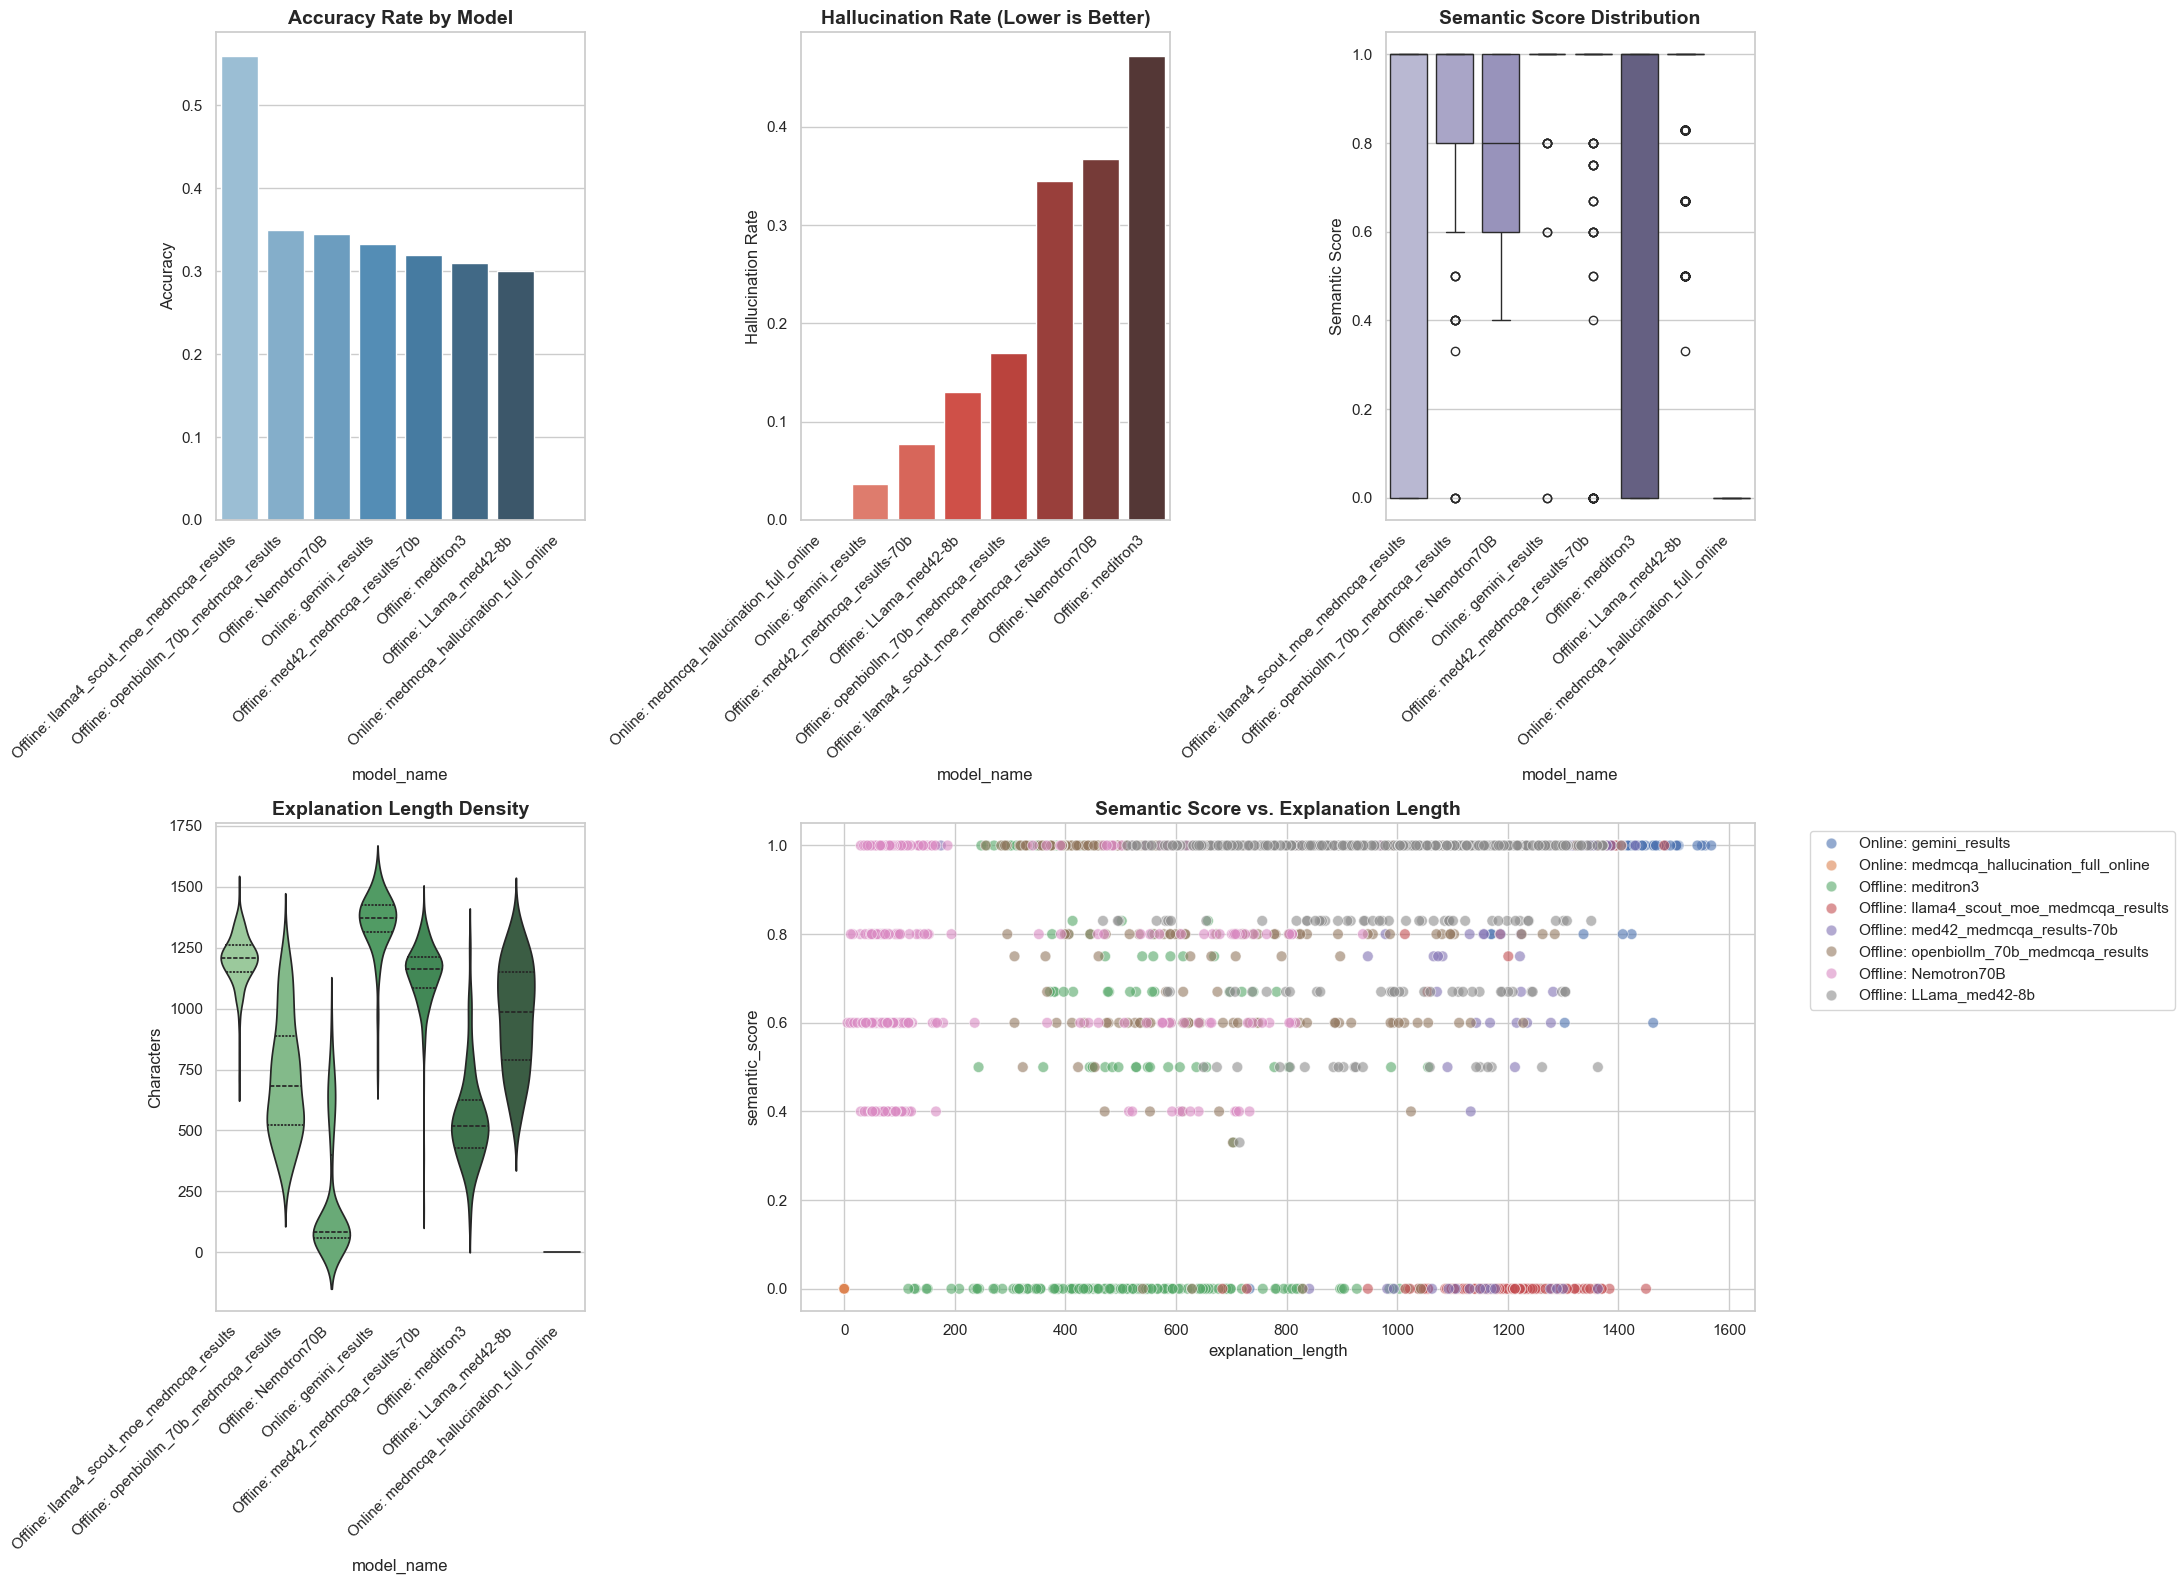

In [22]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Your specified file paths
online_files = [
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/online_llm_medmcqa_gemini_results.csv',
    # '/Users/akshaybusareddy/Gemini3_Flash_Hallucination_Results.csv',
    '/Users/akshaybusareddy/results_final/medmcqa_hallucination_full_online.csv'
]

offline_files = [
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/offline_llm_medmcqa_results_meditron3.csv',
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/llama4_scout_moe_medmcqa_results.csv',
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/med42_medmcqa_results-70b.csv',
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/openbiollm_70b_medmcqa_results.csv',
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/cloud_llm_medmcqa_results_Nemotron70B.csv',
    '/Users/akshaybusareddy/Documents/DA/Online Vs Offline AI Hallucination/Results/offline_llm_medmcqa_results_LLama_med42-8b.csv',
]

def load_and_prep_data():
    """Loops through all files, adds metadata, and combines into one huge DataFrame."""
    dfs = []
    all_files = [(f, 'Online') for f in online_files] + [(f, 'Offline') for f in offline_files]
    
    for file, model_type in all_files:
        if not os.path.exists(file): 
            print(f"[WARNING] File not found on computer: {file}")
            continue
            
        try:
            df = pd.read_csv(file)
            
            # BULLETPROOFING: Strip whitespace and make all column names lowercase
            df.rename(columns=lambda x: str(x).strip().replace('\ufeff', '').lower(), inplace=True)
            
            if 'question' in df.columns:
                df = df[df['question'] != 'SUMMARY_METRICS'].copy()
            else:
                print(f"[ERROR] Skipping {file}: No 'question' column found. Columns found: {list(df.columns)}")
                continue 
            
            # Safely standardize boolean columns
            if 'is_accurate' in df.columns:
                df['is_accurate'] = df['is_accurate'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(bool)
            else:
                df['is_accurate'] = False
                
            if 'is_hallucinating' in df.columns:
                df['is_hallucinating'] = df['is_hallucinating'].map({'True': True, 'False': False, True: True, False: False}).fillna(False).astype(bool)
            else:
                df['is_hallucinating'] = False
                
            if 'semantic_score' in df.columns:
                df['semantic_score'] = pd.to_numeric(df['semantic_score'], errors='coerce')
            else:
                df['semantic_score'] = 0.0
            
            # Handle the explanation column
            if 'explanation_and_medication' in df.columns:
                df['explanation_length'] = df['explanation_and_medication'].astype(str).apply(len)
            elif 'explanation' in df.columns:
                df['explanation_length'] = df['explanation'].astype(str).apply(len)
            else:
                df['explanation_length'] = 0 
                
            # Create a clean model name for charts
            clean_name = os.path.basename(file).replace('.csv', '').replace('offline_llm_medmcqa_results_', '').replace('online_llm_medmcqa_', '').replace('cloud_llm_medmcqa_results_', '')
            
            df['model_name'] = f"{model_type}: {clean_name}"
            df['model_type'] = model_type
            dfs.append(df)
            
        except Exception as e:
            print(f"[ERROR] Could not process {file}. Reason: {e}")
            
    if not dfs:
        raise ValueError("No valid files were processed! Please check the console errors.")
        
    return pd.concat(dfs, ignore_index=True)

# --- 1. LOAD DATA ---
print("Loading datasets...")
all_data = load_and_prep_data()
print(f"Successfully loaded {len(all_data['model_name'].unique())} models with {len(all_data)} total responses.\n")

# --- 2. DEEP INSIGHTS REPORT ---
print("="*50)
print("DEEP INSIGHTS REPORT")
print("="*50)

# Insight 1: Question Difficulty
question_stats = all_data.groupby('question').agg(
    accuracy=('is_accurate', 'mean'),
    times_asked=('model_name', 'count')
).reset_index()

hardest_questions = question_stats[question_stats['accuracy'] == 0.0]
print(f"\n[1] QUESTION DIFFICULTY:")
print(f"Out of {len(question_stats)} unique questions, {len(hardest_questions)} questions were missed by EVERY single model.")

# Insight 2: Verbosity
print("\n[2] VERBOSITY (AVERAGE EXPLANATION LENGTH IN CHARACTERS):")
length_stats = all_data.groupby('model_type')['explanation_length'].mean().round(0)
print(length_stats.to_string())

# Insight 3: Statistical Significance (T-Test)
online_scores = all_data[all_data['model_type'] == 'Online']['semantic_score'].dropna()
offline_scores = all_data[all_data['model_type'] == 'Offline']['semantic_score'].dropna()

if len(online_scores) > 1 and len(offline_scores) > 1:
    t_stat, p_val = stats.ttest_ind(online_scores, offline_scores, equal_var=False)
    print("\n[3] STATISTICAL SIGNIFICANCE (T-TEST ON SEMANTIC SCORES):")
    print(f"P-value: {p_val:.5f}")
    if p_val < 0.05:
        print("Conclusion: The difference in semantic scores between Online and Offline models IS statistically significant.")
    else:
        print("Conclusion: The difference in semantic scores between Online and Offline models is NOT statistically significant.")

# --- 3. GENERATE DASHBOARD PLOTS ---
print("\nGenerating visual dashboard...")
fig = plt.figure(figsize=(22, 16))
sns.set_theme(style="whitegrid")

# Sort models by accuracy for better visualization
model_order_acc = all_data.groupby('model_name')['is_accurate'].mean().sort_values(ascending=False).index

# Plot 1: Accuracy
ax1 = plt.subplot(2, 3, 1)
acc_data = all_data.groupby('model_name')['is_accurate'].mean().reset_index()
sns.barplot(data=acc_data, x='model_name', y='is_accurate', order=model_order_acc, palette='Blues_d', ax=ax1)
ax1.set_title('Accuracy Rate by Model', fontsize=14, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylabel('Accuracy')

# Plot 2: Hallucination Rate
ax2 = plt.subplot(2, 3, 2)
hal_data = all_data.groupby('model_name')['is_hallucinating'].mean().reset_index()
model_order_hal = hal_data.sort_values('is_hallucinating').model_name
sns.barplot(data=hal_data, x='model_name', y='is_hallucinating', order=model_order_hal, palette='Reds_d', ax=ax2)
ax2.set_title('Hallucination Rate (Lower is Better)', fontsize=14, fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylabel('Hallucination Rate')

# Plot 3: Semantic Score Boxplot
ax3 = plt.subplot(2, 3, 3)
sns.boxplot(data=all_data, x='model_name', y='semantic_score', order=model_order_acc, palette='Purples_d', ax=ax3)
ax3.set_title('Semantic Score Distribution', fontsize=14, fontweight='bold')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
ax3.set_ylabel('Semantic Score')

# Plot 4: Explanation Length Violin Plot
ax4 = plt.subplot(2, 3, 4)
sns.violinplot(data=all_data, x='model_name', y='explanation_length', order=model_order_acc, palette='Greens_d', inner='quartile', ax=ax4)
ax4.set_title('Explanation Length Density', fontsize=14, fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.set_ylabel('Characters')

# Plot 5: Semantic Score vs Explanation Length Scatter
ax5 = plt.subplot(2, 3, (5, 6))
sns.scatterplot(data=all_data, x='explanation_length', y='semantic_score', hue='model_name', alpha=0.6, s=60, ax=ax5)
ax5.set_title('Semantic Score vs. Explanation Length', fontsize=14, fontweight='bold')
ax5.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('medmcqa_hallucination_dashboard.png', dpi=300, bbox_inches='tight')
print("Done! Dashboard saved as 'medmcqa_hallucination_dashboard.png'")
def generate_metric_table():
    summary_data = []
    all_files = [(f, 'Online') for f in online_files] + [(f, 'Offline') for f in offline_files]
    
    for file, model_type in all_files:
        if not os.path.exists(file):
            print(f"Skipping: File not found at {file}")
            continue
            
        try:
            df = pd.read_csv(file)
            # Normalize column names
            df.rename(columns=lambda x: str(x).strip().replace('\ufeff', '').lower(), inplace=True)
            
            # Remove summary rows if present
            if 'question' in df.columns:
                df = df[df['question'] != 'SUMMARY_METRICS'].copy()
            
            # Convert Accuracy to boolean
            if 'is_accurate' in df.columns:
                acc_series = df['is_accurate'].map({'True': True, 'False': False, True: True, False: False}).fillna(False)
                accuracy = acc_series.mean()
            else:
                accuracy = 0.0
                
            # Convert Hallucination to boolean
            if 'is_hallucinating' in df.columns:
                hal_series = df['is_hallucinating'].map({'True': True, 'False': False, True: True, False: False}).fillna(False)
                hallucination_rate = hal_series.mean()
            else:
                hallucination_rate = 0.0
            
            # Extract a clean model name
            model_name = os.path.basename(file).split('.')[0].replace('offline_llm_medmcqa_results_', '').replace('online_llm_medmcqa_', '')
            
            summary_data.append({
                'Model Name': model_name,
                'Category': model_type,
                'Accuracy (%)': round(accuracy * 100, 2),
                'Hallucination Rate (%)': round(hallucination_rate * 100, 2)
            })
            
        except Exception as e:
            print(f"Error processing {file}: {e}")

    # Create the final Table
    table_df = pd.DataFrame(summary_data)
    
    # Sort by Accuracy (highest first)
    table_df = table_df.sort_values(by='Accuracy (%)', ascending=False)
    
    return table_df

# Run and Display
final_table = generate_metric_table()

print("\n" + "="*70)
print("CORE PERFORMANCE METRICS: ACCURACY VS HALLUCINATION")
print("="*70)
print(final_table.to_string(index=False))
print("="*70)

# Optional: Save to CSV for your report
# final_table.to_csv('model_performance_summary.csv', index=False)